# IMPORTS

In [17]:
import os
import heapq                      # pending list: always pop the point with the latest t
from datetime import date

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

import stable_baselines3, sb3_contrib
print('numpy', np.__version__, '| gymnasium', gym.__version__,
      '| sb3', stable_baselines3.__version__, '| sb3_contrib', sb3_contrib.__version__)

numpy 2.5.0 | gymnasium 1.3.0 | sb3 2.9.0 | sb3_contrib 2.9.0


# True solution

grid:  nx = 100,  nt = 1090,  dx = 0.0101,  dt = 0.0004591
diffusion number  alpha*dt/dx^2 = 0.450
Courant number    c*dt/dx       = 0.045

check 1  max |u(x,0) - u0(x)|  = 5.65e-07
check 2  |u(0,t)|, |u(1,t)|     = 0.00e+00, 4.76e-17
check 3  PDE residual at (0.5, 75dt) = 2.94e-07   (|u_t| = 1.03e+00)


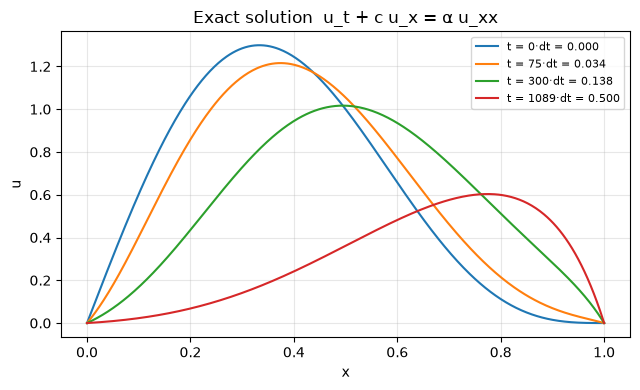

In [18]:
# ── PDE:  u_t + c u_x = alpha u_xx   on x in [0, 1],  u(0,t) = u(1,t) = 0 ──
alpha = 0.1          # diffusion coefficient
c     = 1.0          # advection speed

# ── Grid: every point the map can use sits on this grid ──
nx = 100
T  = 0.5
dx = 1.0 / (nx - 1)
dt_cfl = min(0.9 * dx / c, 0.45 * dx**2 / alpha)     # advective and diffusive limits
nt = max(int(np.ceil(T / dt_cfl)) + 1, 10)
dt = T / (nt - 1)

print(f"grid:  nx = {nx},  nt = {nt},  dx = {dx:.4g},  dt = {dt:.4g}")
print(f"diffusion number  alpha*dt/dx^2 = {alpha * dt / dx**2:.3f}")
print(f"Courant number    c*dt/dx       = {c * dt / dx:.3f}")

# ── Exact solution ──
# u = exp(b x - alpha b^2 t) v  with  b = c / (2 alpha)  removes the advection term;
# v solves the heat equation, so it is a sine series.
_xq = np.linspace(0.0, 1.0, 80001)
_b  = c / (2 * alpha)
u0  = lambda x: np.sin(np.pi * x) + 0.5 * np.sin(2 * np.pi * x)
_v0 = u0(_xq) * np.exp(-_b * _xq)
_n  = np.arange(1, 801)
_bn = np.array([2 * np.trapezoid(_v0 * np.sin(k * np.pi * _xq), _xq) for k in _n])

def u_true(x, t):
    """Exact u at positions x (scalar or array) and one time t. Always returns an array."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    v = (np.sin(np.pi * np.outer(x, _n)) * (_bn * np.exp(-alpha * (_n * np.pi)**2 * t))).sum(axis=1)
    return np.exp(_b * x - alpha * _b**2 * t) * v

# ── Checks ──
xs = np.linspace(0, 1, 501)
tq = 75 * dt
print(f"\ncheck 1  max |u(x,0) - u0(x)|  = {np.abs(u_true(xs, 0.0) - u0(xs)).max():.2e}")
print(f"check 2  |u(0,t)|, |u(1,t)|     = {abs(u_true(0.0, tq)[0]):.2e}, {abs(u_true(1.0, tq)[0]):.2e}")
xc, e = 0.5, 1e-4
u_t  = (u_true(xc, tq + e) - u_true(xc, tq - e))[0] / (2 * e)
u_x  = (u_true(xc + e, tq) - u_true(xc - e, tq))[0] / (2 * e)
u_xx = (u_true(xc + e, tq) - 2 * u_true(xc, tq) + u_true(xc - e, tq))[0] / e**2
print(f"check 3  PDE residual at (0.5, 75dt) = {abs(u_t + c * u_x - alpha * u_xx):.2e}   (|u_t| = {abs(u_t):.2e})")

# ── Picture: the solution at a few times ──
fig, ax = plt.subplots(figsize=(6.5, 4))
for n_lvl in [0, 75, 300, nt - 1]:
    ax.plot(xs, u_true(xs, n_lvl * dt), label=f"t = {n_lvl}·dt = {n_lvl * dt:.3f}")
ax.set(xlabel="x", ylabel="u", title="Exact solution  u_t + c u_x = α u_xx")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# FD Soltuion

FD weights = [0.472727 0.1      0.427273],  sum = 1.000000,  all positive: True

  x*    t* |      u_FD    u_true      E_FD    C_FD
  50    10 |  0.994087  0.994061  2.58e-05     100
  50    75 |  1.042785  1.042593  1.92e-04    4949
  50   200 |  1.060653  1.060205  4.48e-04   17199
  25   200 |  0.763834  0.764044  2.10e-04   16599
  75   200 |  0.491923  0.491799  1.24e-04   16549
  50   500 |  0.845057  0.844783  2.75e-04   46599


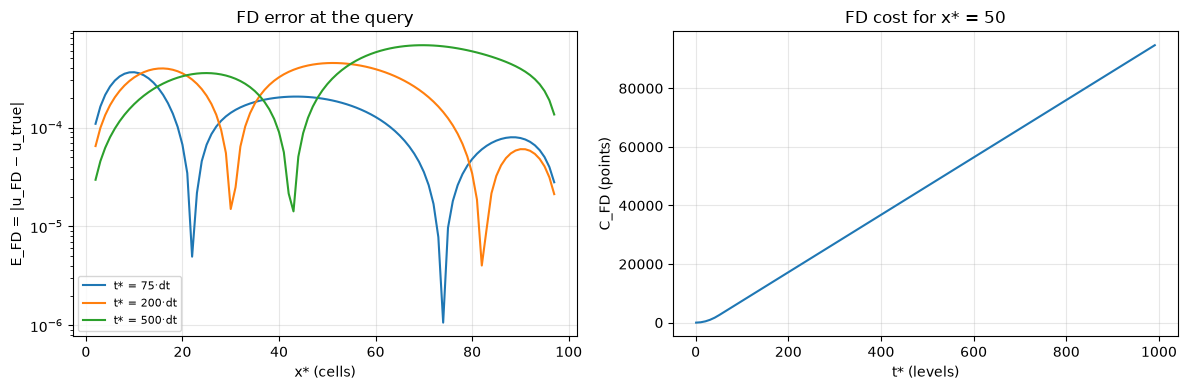

In [19]:
# ── FD reference: the tight central stencil (k=1, W=1, s=0) at every point ──
r, nu = alpha * dt / dx**2, c * dt / dx
W_FD = np.array([r + nu / 2, 1 - 2 * r, r - nu / 2])      # weights for (x-dx, x, x+dx)
print(f"FD weights = {np.round(W_FD, 6)},  sum = {W_FD.sum():.6f},  all positive: {bool((W_FD > 0).all())}")

_fd_cache = {}

def fd_reference(ix, it):
    """FD at z* = (ix, it): (u_fd, E_FD, C_FD). Cached in a dict so the env can be sent to subprocesses."""
    if (ix, it) in _fd_cache:
        return _fd_cache[(ix, it)]
    u = u_true(np.arange(nx) * dx, 0.0)                    # level 0: initial condition
    for _ in range(it):
        u[1:-1] = W_FD[0] * u[:-2] + W_FD[1] * u[1:-1] + W_FD[2] * u[2:]
        u[0] = u[-1] = 0.0                                   # boundaries
    u_fd = u[ix]
    E_FD = abs(u_fd - u_true(ix * dx, it * dt)[0])
    C_FD = sum(min(nx - 2, ix + j) - max(1, ix - j) + 1 for j in range(it))
    _fd_cache[(ix, it)] = (u_fd, E_FD, C_FD)
    return _fd_cache[(ix, it)]

# ── Table for a few queries ──
print(f"\n{'x*':>4} {'t*':>5} | {'u_FD':>9} {'u_true':>9} {'E_FD':>9} {'C_FD':>7}")
for ix, it in [(50, 10), (50, 75), (50, 200), (25, 200), (75, 200), (50, 500)]:
    u_fd, E, C = fd_reference(ix, it)
    print(f"{ix:>4} {it:>5} | {u_fd:9.6f} {u_true(ix * dx, it * dt)[0]:9.6f} {E:9.2e} {C:>7d}")

# ── Picture: FD error across x* (does it dip by luck?) and FD cost vs t* ──
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
ixs = np.arange(2, nx - 2)
for it in [75, 200, 500]:
    a1.semilogy(ixs, [fd_reference(i, it)[1] for i in ixs], label=f"t* = {it}·dt")
a1.set(xlabel="x* (cells)", ylabel="E_FD = |u_FD − u_true|", title="FD error at the query")
a1.legend(fontsize=8); a1.grid(alpha=0.3)

its = np.arange(1, 1001, 10)
a2.plot(its, [fd_reference(50, i)[2] for i in its])
a2.set(xlabel="t* (levels)", ylabel="C_FD (points)", title="FD cost for x* = 50")
a2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Possible Actions


In [20]:
K_LIST = [1, 2]      # depth
W_LIST = [1, 2, 3]           # width
S_LIST = [-1, 0, 1]         # shift

# Solve Weights


In [21]:
def solve_weights(dxs, dts):
    h = max(np.abs(dxs).max(), np.sqrt(alpha * np.abs(dts).max()))
    A = np.array([np.ones_like(dxs),
                  (dxs - c * dts) / h,
                  (0.5 * dxs**2 + alpha * dts) / h**2])
    return np.linalg.lstsq(A, np.array([1.0, 0.0, 0.0]), rcond=None)[0]


TEMPLATES, WEIGHTS = [], []
for k in K_LIST:
    for W in W_LIST:
        for s in S_LIST:
            dix = np.array([s - W, s, s + W])
            w = solve_weights(dix * dx, -k * dt * np.ones(3))
            if w.min() >= -1e-12:                 # keep positive weights only
                TEMPLATES.append((k, W, s))
                WEIGHTS.append(w)
WEIGHTS   = np.array(WEIGHTS)
N_ACTIONS = len(TEMPLATES)

print("actions:", N_ACTIONS)
print("FD template weights:", np.round(WEIGHTS[TEMPLATES.index((1, 1, 0))], 6))

actions: 7
FD template weights: [0.472727 0.1      0.427273]


# Neighbours?

In [22]:

def neighbours(ix, it, a):
    """3 neighbours of action a at (ix, it). Outside the grid -> moved onto the IC or the wall."""
    k, W, s = TEMPLATES[a]
    jt = max(it - k, 0)                                          # below t = 0 -> land on the IC
    return [(min(max(ix + d, 0), nx - 1), jt) for d in (s - W, s, s + W)]   # past a wall -> land on it

_weights_cache = {}

def weights_from_offsets(offsets):
    """Weights for grid offsets ((dix, dit), ...). None if two neighbours coincide or a weight < 0."""
    if offsets not in _weights_cache:
        w = None
        if len(set(offsets)) == 3:
            dxs = np.array([o[0] for o in offsets]) * dx
            dts = np.array([o[1] for o in offsets]) * dt
            w = solve_weights(dxs, dts)
            if w.min() < -1e-12:
                w = None
        _weights_cache[offsets] = w
    return _weights_cache[offsets]

def stencil_weights(ix, it, a):
    """Weights of action a at (ix, it), for the neighbours' real positions."""
    offsets = tuple((jx - ix, jt - it) for jx, jt in neighbours(ix, it, a))
    return weights_from_offsets(offsets)

def action_mask(ix, it):
    """True where the action gives 3 distinct neighbours with weights >= 0."""
    return np.array([stencil_weights(ix, it, a) is not None for a in range(N_ACTIONS)])


In [23]:
def is_known(ix, it):
    """Initial condition or boundary: the value is free."""
    return it == 0 or ix == 0 or ix == nx - 1

print(is_known(50, 0), is_known(0, 30), is_known(50, 30))

# pending list: latest t first, ties left to right
pending = []
for ix, it in [(50, 70), (52, 74), (48, 74), (50, 74)]:
    heapq.heappush(pending, (-it, ix))

while pending:
    neg_it, ix = heapq.heappop(pending)
    print((ix, -neg_it))

True True False
(48, 74)
(50, 74)
(52, 74)
(50, 70)


In [24]:
FD_ACTION = TEMPLATES.index((1, 1, 0))

def start_map(ix, it):
    """Empty map for the query z* = (ix, it)."""
    pending = [(-it, ix)]      # points waiting for a stencil
    seen    = {(ix, it)}       # every computed point created so far
    stencil = {}               # point -> chosen action
    return pending, seen, stencil

def build_step(pending, seen, stencil, a):
    """Pop the next point, give it action a, add its new neighbours. Returns (point, n_new)."""
    neg_it, ix = heapq.heappop(pending)
    p = (ix, -neg_it)
    stencil[p] = a
    n_new = 0
    for q in neighbours(*p, a):
        if not is_known(*q) and q not in seen:
            seen.add(q)
            heapq.heappush(pending, (-q[1], q[0]))
            n_new += 1
    return p, n_new

# first 4 steps with FD
pending, seen, stencil = start_map(50, 75)
for _ in range(4):
    p, n_new = build_step(pending, seen, stencil, FD_ACTION)
    print(p, " new:", n_new, " pending:", len(pending))

# finish the whole map with FD
while pending:
    build_step(pending, seen, stencil, FD_ACTION)
print("points in FD map:", len(seen))

(50, 75)  new: 3  pending: 3
(49, 74)  new: 3  pending: 5
(50, 74)  new: 1  pending: 5
(51, 74)  new: 1  pending: 5
points in FD map: 4949


In [25]:
U0 = u_true(np.arange(nx) * dx, 0.0)          # initial condition on the grid

def known_value(ix, it):
    """Value of a known point: the IC at t = 0, zero on the walls."""
    return U0[ix] if it == 0 else 0.0

def evaluate(stencil):
    """Forward pass: compute u_hat at every point of the map, earliest t first."""
    u_hat = {}
    for p in sorted(stencil, key=lambda p: p[1]):
        a = stencil[p]
        vals = [known_value(*q) if is_known(*q) else u_hat[q] for q in neighbours(*p, a)]
        u_hat[p] = stencil_weights(*p, a) @ vals
    return u_hat

# the FD map built in Cell 7 for z* = (50, 75)
u_hat = evaluate(stencil)
u_star = u_true(50 * dx, 75 * dt)[0]
print(f"u_hat(z*)  = {u_hat[(50, 75)]:.6f}")
print(f"u_true(z*) = {u_star:.6f}")
print(f"|error|    = {abs(u_hat[(50, 75)] - u_star):.2e}")

u_hat(z*)  = 1.042785
u_true(z*) = 1.042593
|error|    = 1.92e-04


# RL Environment

In [26]:
def count_new(ix, it, a, seen):
    """How many new computed points action a would create at (ix, it)."""
    return sum(1 for q in set(neighbours(ix, it, a)) if not is_known(*q) and q not in seen)

class BackwardMapEnv(gym.Env):
    def __init__(self, queries, w_err=1.0, w_cost=1.0, e_tol=1e-4):
        super().__init__()
        self.queries = queries                     # list of z* = (ix, it), one sampled per episode
        self.w_err, self.w_cost, self.e_tol = w_err, w_cost, e_tol
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(2 + N_ACTIONS,), dtype=np.float32)
        self.action_space = spaces.Discrete(N_ACTIONS)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.z_star = self.queries[self.np_random.integers(len(self.queries))]
        self.pending, self.seen, self.stencil = start_map(*self.z_star)
        return self._obs(), {}

    def _current(self):
        """The next point to expand (latest t first), not popped yet."""
        neg_it, ix = self.pending[0]
        return ix, -neg_it

    def _obs(self):
        ix, it = self._current()
        n_new = [count_new(ix, it, a, self.seen) for a in range(N_ACTIONS)]
        return np.array([ix, it, *n_new], dtype=np.float32)

env = BackwardMapEnv(queries=[(50, 75)])
obs, _ = env.reset(seed=0)

## Stepping step


In [27]:
def step(self, a):
    build_step(self.pending, self.seen, self.stencil, a)
    if self.pending:                                           # map not finished: no reward yet
        return self._obs(), 0.0, False, False, {}

    # map finished: forward pass, then the terminal reward
    ix, it = self.z_star
    u_hat  = evaluate(self.stencil)[self.z_star]
    err    = abs(u_hat - u_true(ix * dx, it * dt)[0])
    N, C   = len(self.seen), fd_reference(ix, it)[2]
    r_acc  = -self.w_err * np.log10(max(err, 1e-3 * self.e_tol) / self.e_tol) / 3
    r_cost = -self.w_cost * np.log10(N / C) / 3
    info   = {"error": float(err), "n_points": N, "r_acc": float(r_acc), "r_cost": float(r_cost)}
    return np.zeros(self.observation_space.shape, np.float32), r_acc + r_cost, True, False, info

def action_masks(self):
    return action_mask(*self._current())

BackwardMapEnv.step = step
BackwardMapEnv.action_masks = action_masks

## Plotting

In [28]:
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm

def plot_map(model, x_star, t_star, e_tol=1e-4, save=True, timestep=None, img_dir=".", label=None):
    # ── deterministic rollout ──
    env = BackwardMapEnv(queries=[(x_star, t_star)], e_tol=e_tol)
    obs, _ = env.reset(seed=0)
    done = False
    while not done:
        a, _ = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
        obs, reward, done, _, info = env.step(int(a))

    # ── values, errors, stencil lines ──
    u_hat = evaluate(env.stencil)
    pts   = np.array(list(u_hat.keys()))
    err   = np.array([abs(u_hat[(ix, it)] - u_true(ix * dx, it * dt)[0]) for ix, it in pts])
    depth = np.array([TEMPLATES[env.stencil[tuple(p)]][0] for p in pts])
    lines = [[p, q] for p, a in env.stencil.items() for q in neighbours(*p, a)]
    line_depth = [TEMPLATES[a][0] for p, a in env.stencil.items() for q in neighbours(*p, a)]
    known = np.array(sorted({tuple(l[1]) for l in lines if is_known(*l[1])}))

    u_pred, u_ref = u_hat[(x_star, t_star)], u_true(x_star * dx, t_star * dt)[0]
    depth_norm = LogNorm(vmin=1, vmax=max(K_LIST))
    err_norm   = LogNorm(vmin=1e-6, vmax=1e-2)

    def draw(ax, size):
        ax.add_collection(LineCollection(lines, array=np.array(line_depth), cmap="cool",
                                         norm=depth_norm, lw=0.7, alpha=0.6))
        ax.scatter(known[:, 0], known[:, 1], s=size, marker="s", color="orange", zorder=2, label="known data")
        sc = ax.scatter(pts[:, 0], pts[:, 1], s=size, c=np.maximum(err, 1e-16), cmap="viridis",
                        norm=err_norm, edgecolors="k", linewidths=0.3, zorder=3)
        ax.plot(x_star, t_star, "r*", ms=18, mec="k", zorder=4, label="z*")
        ax.set(xlabel="x (cells)", ylabel="t (levels)")
        return sc

    fig, ((axL, axR), (axS, axE)) = plt.subplots(2, 2, figsize=(15, 11))

    # top-left: full map, lines coloured by template depth, points by their error
    sc = draw(axL, 12)
    axL.set(xlim=(-1, nx), ylim=(-2, t_star + 3), title=f"Map: {len(pts)} computed points")
    axL.legend(loc="upper left", fontsize=8)
    fig.colorbar(sc, ax=axL, label="|u_hat − u_true| at each point")

    # top-right: zoom near z*
    sc = draw(axR, 60)
    axR.set(xlim=(x_star - 15, x_star + 15), ylim=(t_star - 20, t_star + 2), title="Zoom near z*")
    lc = axR.collections[0]
    fig.colorbar(lc, ax=axR, label="template depth k")

    # bottom-left: solution at t*, predicted vs true
    xs = np.linspace(0, 1, 400)
    axS.plot(xs, u_true(xs, 0.0), ":", color="gray", label="initial condition")
    axS.plot(xs, u_true(xs, t_star * dt), "k-", lw=2, label="exact u(x, t*)")
    axS.plot(x_star * dx, u_ref, "o", ms=12, mfc="none", mec="k", mew=2, label="true value at z*")
    axS.plot(x_star * dx, u_pred, "r*", ms=16, mec="k", label="predicted at z*")
    axS.text(0.03, 0.05, f"predicted  u_hat(z*) = {u_pred:.6f}\ntrue       u(z*)     = {u_ref:.6f}\n"
                         f"error                = {abs(u_pred - u_ref):.2e}",
             transform=axS.transAxes, family="monospace", fontsize=10,
             bbox=dict(boxstyle="round", fc="lightyellow", ec="gray"))
    axS.set(xlabel="x", ylabel="u", title="Solution at t*")
    axS.legend(fontsize=8, loc="upper right")

    # bottom-right: error of every point vs t, coloured by template depth
    sc = axE.scatter(pts[:, 1], np.maximum(err, 1e-16), s=12, c=depth, cmap="cool", norm=depth_norm)
    fig.colorbar(sc, ax=axE, label="template depth k")
    axE.axhline(e_tol, color="green", ls="--", label=f"e_tol = {e_tol:g}")
    axE.plot(t_star, max(info["error"], 1e-16), "r*", ms=16, mec="k", label="z*")
    axE.set(yscale="log", xlabel="t (levels)", ylabel="|u_hat − u_true|", title="Error of every computed point")
    axE.legend(fontsize=8)

    sup = (f"z* = ({x_star}, {t_star})  |  reward = {reward:.3f}  (accuracy {info['r_acc']:.3f}, "
           f"cost {info['r_cost']:.3f})  |  points = {info['n_points']}")
    if timestep is not None:
        sup += f"  |  step {timestep:,}"
    fig.suptitle(sup, fontsize=13)
    plt.tight_layout()

    if save:
        tag = label if label is not None else f"{timestep // 1000:05d}k"
        fig.savefig(os.path.join(img_dir, f"backward_t{t_star}dt_x{x_star}_{tag}.png"), dpi=120)
        plt.close(fig)
    else:
        plt.show()
    return info

In [29]:
class MetricsCallback(BaseCallback):
    """At the end of each episode, log error, points, r_acc, r_cost (mean of the last 100)."""
    def __init__(self):
        super().__init__()
        self.hist = {"error": [], "n_points": [], "r_acc": [], "r_cost": []}

    def _on_step(self):
        for info in self.locals["infos"]:
            if "error" in info:                                    # only the last step of an episode has it
                for key in self.hist:
                    self.hist[key].append(info[key])
        for key, vals in self.hist.items():
            if vals:
                self.logger.record(f"rollout/mean_{key}", np.mean(vals[-100:]))
        return True

class PlotCallback(BaseCallback):
    """Every plot_freq steps, save a plot_map figure."""
    def __init__(self, x_star, t_star, e_tol, img_dir, plot_freq=100_000):
        super().__init__()
        self.x_star, self.t_star, self.e_tol = x_star, t_star, e_tol
        self.img_dir, self.plot_freq, self.last = img_dir, plot_freq, 0

    def _on_step(self):
        if self.num_timesteps - self.last >= self.plot_freq:
            self.last = self.num_timesteps
            plot_map(self.model, self.x_star, self.t_star, e_tol=self.e_tol,
                     save=True, timestep=self.num_timesteps, img_dir=self.img_dir)
        return True

def make_env(queries, e_tol):
    def _init():
        env = BackwardMapEnv(queries=queries, e_tol=e_tol)
        env = ActionMasker(env, lambda e: e.action_masks())
        return Monitor(env)
    return _init



In [30]:
x_star, t_star  = 50, 40
queries         = [(x_star, t_star)]         # z* sampled per episode (one for now)
e_tol           = 1e-4
seeds           = [0]

n_envs          = 12
n_steps         = 2048
batch_size      = 1024
total_timesteps = 2_000_000
plot_freq       = 10_000

# ── Run directory ──
day, month = date.today().day, date.today().month
run_name   = f"t{t_star}_x{x_star}_etol{e_tol}"
run_dir    = os.path.join(f"runs_backward_{month}-{day}", run_name)
print("Run:", run_dir)

for seed in seeds:
    seed_dir = os.path.join(run_dir, f"seed{seed}")
    img_dir  = os.path.join(seed_dir, "images")
    ckpt_dir = os.path.join(seed_dir, "checkpoints")
    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)
    print(f"\n{'#' * 50}\nSEED {seed}\n{'#' * 50}")

    vec_env = SubprocVecEnv([make_env(queries, e_tol) for _ in range(n_envs)])

    model = MaskablePPO("MlpPolicy", vec_env, gamma=1.0, n_steps=n_steps, batch_size=batch_size,
                        learning_rate=2e-4, clip_range=0.1, ent_coef=0.01, seed=seed, verbose=1,
                        tensorboard_log=os.path.join(seed_dir, "logs"), device="cpu")

    model.learn(total_timesteps=total_timesteps, tb_log_name=f"seed{seed}", log_interval=2,
                callback=[MetricsCallback(),
                          PlotCallback(x_star, t_star, e_tol, img_dir, plot_freq=plot_freq),
                          CheckpointCallback(save_freq=100_000 // n_envs, save_path=ckpt_dir,
                                             name_prefix="backward")])

    model.save(os.path.join(ckpt_dir, "backward_final"))
    plot_map(model, x_star, t_star, e_tol=e_tol, save=True, img_dir=img_dir, label="final")
    vec_env.close()

Run: runs_backward_9-17\t40_x50_etol0.0001

##################################################
SEED 0
##################################################
Using cpu device
Logging to runs_backward_9-17\t40_x50_etol0.0001\seed0\logs\seed0_1
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 2.03e+03     |
|    ep_rew_mean          | 0.00925      |
|    mean_error           | 8.99e-05     |
|    mean_n_points        | 2.03e+03     |
|    mean_r_acc           | 0.0432       |
|    mean_r_cost          | -0.0339      |
| time/                   |              |
|    fps                  | 4763         |
|    iterations           | 2            |
|    time_elapsed         | 10           |
|    total_timesteps      | 49152        |
| train/                  |              |
|    approx_kl            | 0.0019088881 |
|    clip_fraction        | 0.0338       |
|    clip_range           | 0.1          |
|    entropy_loss         | -1.

in menu (all weights >= 0): False


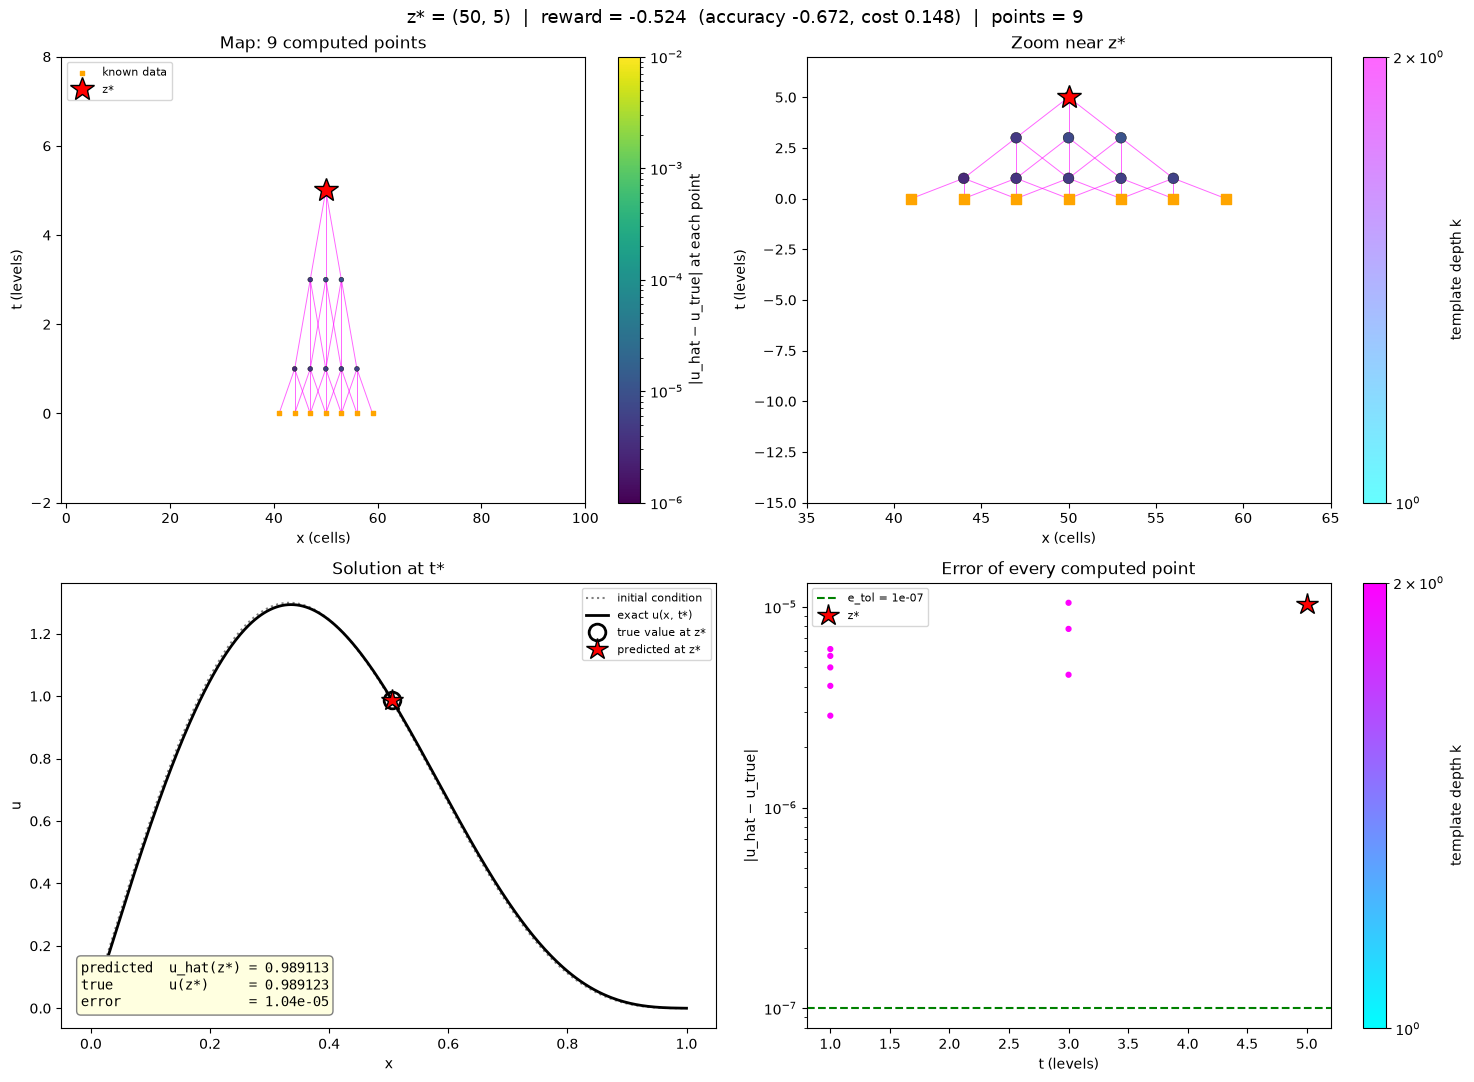

error = 1.04e-05   points = 9   reward = -0.5241   (FD: -0.0947)


In [31]:
# ── Parameters to play with ──
x_star, t_star = 50, 5
k, W, s        = 8, 4, 0          # template to use everywhere (depth, width, shift)
e_tol          = 1e-7

class FixedTemplate:
    """Acts like a model: uses (k, W, s) where allowed, otherwise the closest allowed template."""
    def __init__(self, k, W, s):
        self.target = np.array([k, W, s])
    def predict(self, obs, action_masks, deterministic=True):
        allowed = np.flatnonzero(action_masks)
        dist = [np.abs(np.array(TEMPLATES[a]) - self.target).sum() for a in allowed]
        return allowed[int(np.argmin(dist))], None

print("in menu (all weights >= 0):", (k, W, s) in TEMPLATES)
if (k, W, s) in TEMPLATES:
    print("weights at an interior point:", np.round(WEIGHTS[TEMPLATES.index((k, W, s))], 4))

info = plot_map(FixedTemplate(k, W, s), x_star, t_star, e_tol=e_tol, save=False)
print(f"error = {info['error']:.2e}   points = {info['n_points']}   "
      f"reward = {info['r_acc'] + info['r_cost']:.4f}   (FD: -0.0947)")